## Veri Setini Tanıma

Veri Setini Tanıma
Amaç:

1. Veri setinin genel yapısını tanımak ve temel özelliklerini incelemek
2. Veri analizi öncesi gerekli ilk kontrolleri uygulamak

Adımlar:

1. Veri setini yükle
2. Veri setinin ilk ve son satırlarını incele
3. Veri setinin boyutunu ve sütunlarını kontrol etmek
4. Veri setinin genel bilgisini incele
5. Özet istatistikleri görüntüle
6. Veri tiplerini kontrol et
7. Sayısal ve kategorik sütunları ayırmak
8. Benzersiz (unique) değer sayılarını incelemek

In [1]:
import pandas as pd

In [2]:
# 1. Veri setini yükleme
df = pd.read_csv("e_ticaret_veri_seti.csv")

In [4]:
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03


In [5]:
# 2. Veri setinin ilk ve son satırlarını incele
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03


In [8]:
df.shape # Data frame shape komutu bir Tuple verir.

(1428, 18)

##### Dataframe shape 0.index'i alındığında satır, 1.index alındığında sütun sayısını verir.

In [6]:
# 3. Veri setinin boyutunu ve sütunlarını kontrol etme
satir_sayisi = df.shape[0]
satir_sayisi

1428

In [9]:
sutun_sayisi = df.shape[1]
sutun_sayisi

18

In [11]:
# sütun isimleri
for i, sutun in enumerate(df.columns, start = 1): ## Index 0'dam başlar ancak numaralandırma 1'den başlasın diye start=1 dedil
 print(f"{i}. {sutun}")

1. siparis_id
2. musteri_id
3. siparis_tarihi
4. sehir
5. bolge
6. kategori
7. urun_adi
8. adet
9. birim_fiyat
10. indirim_orani
11. kargo_ucreti
12. odeme_turu
13. musteri_tipi
14. teslimat_gunu
15. musteri_puani
16. iade_durumu
17. kar_marji_orani
18. toplam_tutar


##### Sipariş Tarihi DateTime olması gerekirken Object olduğu görülür. Değiştirilmesi gerek, ayrıca null değerler var.

In [12]:
# 4. Veri setinin genel bilgisini inceleme
df.info() # sütun isimlerini, veri tiplerini, missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   siparis_id       1428 non-null   object 
 1   musteri_id       1428 non-null   object 
 2   siparis_tarihi   1428 non-null   object 
 3   sehir            1403 non-null   object 
 4   bolge            1428 non-null   object 
 5   kategori         1428 non-null   object 
 6   urun_adi         1428 non-null   object 
 7   adet             1428 non-null   int64  
 8   birim_fiyat      1428 non-null   float64
 9   indirim_orani    1412 non-null   float64
 10  kargo_ucreti     1428 non-null   float64
 11  odeme_turu       1393 non-null   object 
 12  musteri_tipi     1386 non-null   object 
 13  teslimat_gunu    1400 non-null   float64
 14  musteri_puani    1372 non-null   float64
 15  iade_durumu      1428 non-null   object 
 16  kar_marji_orani  1428 non-null   float64
 17  toplam_tutar  

##### Sayısal Sütunların Temel İstatistik Özellikleri

In [15]:
# Özet istatistikleri görüntüleme
df.describe() # sayısal sütunlar için temel istatistikler

,adet,birim_fiyat,indirim_orani,kargo_ucreti,teslimat_gunu,musteri_puani,kar_marji_orani,toplam_tutar
count,1428.000000,1428.000000,1412.000000,1428.000000,1400.000000,1372.000000,1428.000000,1428.000000
mean,2.136555,658.477654,0.052054,39.725140,3.370714,4.002187,0.302799,1370.590336
std,2.015770,1042.414639,0.060115,14.185017,1.825990,1.096707,0.069795,2961.689500
min,1.000000,93.110000,0.000000,0.000000,1.000000,0.000000,0.180000,89.680000
25%,1.000000,199.185000,0.000000,29.900000,2.000000,3.000000,0.244750,323.855000
50%,2.000000,287.120000,0.050000,39.900000,3.000000,4.000000,0.305000,669.135000
75%,3.000000,819.177500,0.100000,49.900000,4.000000,5.000000,0.362000,1390.950000
max,38.000000,18145.230000,0.200000,59.900000,31.000000,7.000000,0.420000,63870.200000


In [16]:
# 6. Veri tiplerini kontrol etme
df.dtypes

siparis_id          object
musteri_id          object
siparis_tarihi      object
sehir               object
bolge               object
kategori            object
urun_adi            object
adet                 int64
birim_fiyat        float64
indirim_orani      float64
kargo_ucreti       float64
odeme_turu          object
musteri_tipi        object
teslimat_gunu      float64
musteri_puani      float64
iade_durumu         object
kar_marji_orani    float64
toplam_tutar       float64
dtype: object

In [18]:
# 7. Sayısal ve kategorik sütunların ayrılması
# sayısal: float64, int64
sayisal_sutunlar = df.select_dtypes(include=["int64", "float64"]).columns
sayisal_sutunlar

Index(['adet', 'birim_fiyat', 'indirim_orani', 'kargo_ucreti', 'teslimat_gunu',
       'musteri_puani', 'kar_marji_orani', 'toplam_tutar'],
      dtype='object')

In [19]:
# 8. Benzersiz (unique) değer sayılarını incelemek
for sutun in df.columns:
  print(f"{sutun}: {df[sutun].nunique()}")

siparis_id: 1400
musteri_id: 422
siparis_tarihi: 1398
sehir: 19
bolge: 6
kategori: 15
urun_adi: 30
adet: 10
birim_fiyat: 1381
indirim_orani: 5
kargo_ucreti: 5
odeme_turu: 12
musteri_tipi: 7
teslimat_gunu: 11
musteri_puani: 8
iade_durumu: 2
kar_marji_orani: 241
toplam_tutar: 1397


## Kayıp Veri (Missing Value)

Amaç:

1. Eksik veri tespiti ve farklı eksik veri çözüm yöntemlerini uygulamak
2. Kullanılacak güncel veri setini kaydetme

Adımlar:

1. Veri setini yükleme
2. Eksik verileri tespit etme
3. Eksik veri oranlarını hesaplama
4. Eksik veri içeren satırları incele
5. Eksik verileri silmek
6. Sayısal eksik verileri ortalama ile doldur
7. Sayısal eksik verileri medyan ile doldur
8. Sayısal eksik verileri mod ile doldur
9. Kategorik eksik verileri mod ile doldur
10. Kategorik eksik verileri sabit bir değer ile doldurmak
11. Eğitimde kullanılacak olan güncel veri setini oluştur
12. Düzenlenmiş veri setini kaydet

In [21]:
import pandas as pd

In [22]:
# 1. veri setini yükle
df = pd.read_csv("e_ticaret_veri_seti.csv")

In [23]:
# 2. eksik verileri tespit etme
df.isnull().sum()

siparis_id          0
musteri_id          0
siparis_tarihi      0
sehir              25
bolge               0
kategori            0
urun_adi            0
adet                0
birim_fiyat         0
indirim_orani      16
kargo_ucreti        0
odeme_turu         35
musteri_tipi       42
teslimat_gunu      28
musteri_puani      56
iade_durumu         0
kar_marji_orani     0
toplam_tutar        0
dtype: int64

In [24]:
# 3. eksik veri oranlarını hesapla
eksik_sayilari = df.isnull().sum()
eksik_oranlari = 100 * (eksik_sayilari / len(df))
eksik_oranlari

siparis_id         0.000000
musteri_id         0.000000
siparis_tarihi     0.000000
sehir              1.750700
bolge              0.000000
kategori           0.000000
urun_adi           0.000000
adet               0.000000
birim_fiyat        0.000000
indirim_orani      1.120448
kargo_ucreti       0.000000
odeme_turu         2.450980
musteri_tipi       2.941176
teslimat_gunu      1.960784
musteri_puani      3.921569
iade_durumu        0.000000
kar_marji_orani    0.000000
toplam_tutar       0.000000
dtype: float64

In [25]:
# 4. eksik veri içeren satırları incele
eksik_veri_olan_satirlar = df[df.isnull().any(axis = 1)]
eksik_veri_olan_satirlar.head(10)

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
19,SIP100677,MUS1148,2024-07-11 16:24:00,Adana,Akdeniz,Spor,Dambıl Seti,4,1517.65,0.0,29.9,Kapıda Ödeme,Mevcut,3.0,NaN,Hayır,0.311,6100.50
33,SIP101126,MUS1406,2024-09-11 20:05:00,Mersin,Akdeniz,Elektronik,Bluetooth Hoparlör,1,1159.89,0.1,39.9,Kredi Kartı,NaN,2.0,4.0,Hayır,0.204,1083.80
50,SIP101040,MUS1386,2025-04-01 09:30:00,Trabzon,Karadeniz,Spor,Dambıl Seti,1,1554.15,0.0,49.9,Banka Kartı,NaN,4.0,5.0,Hayır,0.217,1604.05
60,SIP100890,MUS1271,2024-11-07 19:47:00,İzmir,Ege,Kitap,Girişimcilik,4,216.38,NaN,49.9,Kredi Kartı,Yeni,1.0,3.0,Hayır,0.199,915.42
61,SIP101317,MUS1060,2024-09-05 20:49:00,NaN,Akdeniz,Ev ve Yaşam,Saklama Kutusu,1,233.63,0.1,29.9,Dijital Cüzdan,Yeni,5.0,2.0,Hayır,0.385,240.17
70,SIP100715,MUS1033,2024-11-10 21:50:00,İstanbul,Marmara,Ev ve Yaşam,Termos,1,552.05,0.0,39.9,NaN,Mevcut,2.0,3.0,Hayır,0.185,591.95
82,SIP100807,MUS1431,2025-01-07 14:12:00,Ankara,İç Anadolu,Kozmetik,Güneş Kremi,1,451.28,0.0,49.9,Kredi Kartı,NaN,4.0,5.0,Hayır,0.315,501.18
84,SIP100679,MUS1310,2024-05-20 18:51:00,İzmir,Ege,Ev ve Yaşam,Termos,2,477.62,0.0,49.9,Kredi Kartı,Mevcut,NaN,4.0,Hayır,0.323,1005.14
86,SIP101071,MUS1131,2024-09-18 12:24:00,NaN,İç Anadolu,Elektronik,Powerbank,1,816.74,0.0,39.9,Banka Kartı,Yeni,3.0,5.0,Hayır,0.301,856.64
92,SIP101366,MUS1347,2025-03-04 14:00:00,Bursa,Marmara,Ev ve Yaşam,Organizer,1,272.40,0.0,29.9,Kredi Kartı,Mevcut,1.0,NaN,Hayır,0.212,302.30


In [28]:
# 5. Eksik verileri silme
df_silinen = df.dropna() # dropna ile eksik değer içeren satırları veri setinden çıkarttık

In [29]:
df_silinen

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1422,SIP101222,MUS1440,2025-05-14 09:21:00,Bursa,Marmara,Spor,Dambıl Seti,1,1488.18,0.00,29.9,Kredi Kartı,Mevcut,3.0,4.0,Hayır,0.189,1518.08
1423,SIP101093,MUS1187,2024-06-08 20:42:00,İstanbul,Marmara,Spor,Yoga Matı,1,772.23,0.00,29.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.275,802.13
1424,SIP101193,MUS1297,2025-11-06 08:17:00,Gaziantep,Güneydoğu Anadolu,Spor,Suluk,2,187.03,0.00,59.9,Kredi Kartı,Yeni,2.0,4.0,Evet,0.243,433.96
1426,SIP101060,MUS1189,2025-04-19 21:52:00,Kocaeli,Marmara,Kitap,Veri Bilimi 101,2,248.55,0.05,59.9,banka karti,Yeni,4.0,3.0,Hayır,0.373,532.14


In [30]:
df_silinen.shape

(1239, 18)

In [31]:
# 6. Sayısal eksik verilerin ortalama ile doldurulması
df_ortalama = df.copy()
sayisal_sutunlar = df_ortalama.select_dtypes(include = ["int64", "float64"]).columns
sayisal_sutunlar

Index(['adet', 'birim_fiyat', 'indirim_orani', 'kargo_ucreti', 'teslimat_gunu',
       'musteri_puani', 'kar_marji_orani', 'toplam_tutar'],
      dtype='object')

In [32]:
for sutun in sayisal_sutunlar:
  df_ortalama[sutun] = df_ortalama[sutun].fillna(df_ortalama[sutun].mean())

In [33]:
df_ortalama[sayisal_sutunlar].isnull().sum()

adet               0
birim_fiyat        0
indirim_orani      0
kargo_ucreti       0
teslimat_gunu      0
musteri_puani      0
kar_marji_orani    0
toplam_tutar       0
dtype: int64

In [34]:
# 7. sayısal eksik verileri medyan ile doldurma
df_medyan = df.copy()
for sutun in sayisal_sutunlar:
  df_medyan[sutun] = df_medyan[sutun].fillna(df_medyan[sutun].median())
df_medyan[sayisal_sutunlar].isnull().sum()

adet               0
birim_fiyat        0
indirim_orani      0
kargo_ucreti       0
teslimat_gunu      0
musteri_puani      0
kar_marji_orani    0
toplam_tutar       0
dtype: int64

In [35]:
# 8. Sayısal eksik verileri mod ile doldurma
df_mod_sayisal = df.copy()
for sutun in sayisal_sutunlar:
  mod_degeri = df_mod_sayisal[sutun].mode()[0] ## Mod liste içerisinde değer ürettiğinden 0.indexini alacağız.
  df_mod_sayisal[sutun] = df_mod_sayisal[sutun].fillna(mod_degeri)
df_mod_sayisal[sayisal_sutunlar].isnull().sum()

adet               0
birim_fiyat        0
indirim_orani      0
kargo_ucreti       0
teslimat_gunu      0
musteri_puani      0
kar_marji_orani    0
toplam_tutar       0
dtype: int64

In [36]:
# 9. kategorik eksik verileri mod ile doldurma
df_mod_kategorik = df.copy()
kategorik_sutunlar = df_mod_kategorik.select_dtypes(include = ["object"]).columns
kategorik_sutunlar

Index(['siparis_id', 'musteri_id', 'siparis_tarihi', 'sehir', 'bolge',
       'kategori', 'urun_adi', 'odeme_turu', 'musteri_tipi', 'iade_durumu'],
      dtype='object')

In [37]:
for sutun in kategorik_sutunlar:
  mod_degeri = df_mod_kategorik[sutun].mode()[0]
  df_mod_kategorik[sutun] = df_mod_kategorik[sutun].fillna(mod_degeri)

In [38]:
df_mod_kategorik[kategorik_sutunlar].isnull().sum()

siparis_id        0
musteri_id        0
siparis_tarihi    0
sehir             0
bolge             0
kategori          0
urun_adi          0
odeme_turu        0
musteri_tipi      0
iade_durumu       0
dtype: int64

In [39]:
# 10. kategorik eksik verileri sabit bir değer ile dolduralım
df_sabit_kategorik = df.copy()

for sutun in kategorik_sutunlar:
  df_sabit_kategorik[sutun] = df_sabit_kategorik[sutun].fillna("Bilinmiyor")

In [40]:
df_sabit_kategorik[kategorik_sutunlar].isnull().sum()

siparis_id        0
musteri_id        0
siparis_tarihi    0
sehir             0
bolge             0
kategori          0
urun_adi          0
odeme_turu        0
musteri_tipi      0
iade_durumu       0
dtype: int64

In [42]:
# 11. Kullanacağımız güncel veri seti
# sayısal eksik verileri medyan ile doldur
# kategorik eksik verileri mod ile doldur

In [43]:
df_guncel = df.copy()

In [44]:
for sutun in sayisal_sutunlar:
  df_guncel[sutun] = df_guncel[sutun].fillna(df_guncel[sutun].median())

In [45]:
for sutun in kategorik_sutunlar:
  mod_degeri = df_guncel[sutun].mode()[0]
  df_guncel[sutun] = df_guncel[sutun].fillna(mod_degeri)

In [46]:
df_guncel.isnull().sum()

siparis_id         0
musteri_id         0
siparis_tarihi     0
sehir              0
bolge              0
kategori           0
urun_adi           0
adet               0
birim_fiyat        0
indirim_orani      0
kargo_ucreti       0
odeme_turu         0
musteri_tipi       0
teslimat_gunu      0
musteri_puani      0
iade_durumu        0
kar_marji_orani    0
toplam_tutar       0
dtype: int64

In [47]:
# 12. düzenlenmiş veri setini kaydedelim
kayit_dosyasi = "e_ticaret_veri_seti_eksik_veriler_duzenlendi.csv"
df_guncel.to_csv(kayit_dosyasi, index = False)

## Veri Tipleri ve Dönüşümler

Amaç:

1. Veri setindeki sütunların veri tiplerini incelemek ve gerekli dönüşümleri uygulamak
2. Kullanılacak güncel veri setini oluşturarak kaydetmek

Adımlar:

1. Veri setini yüklemek
2. Veri tiplerini incelemek
3. Sayısal, kategorik ve tarih sütunlarını belirlemek
4. Sipariş tarihi sütununu datetime tipine dönüştürmek (string -> datetime)
5. Tarih sütunundan yeni özellikler üretmek (Feature extraction)
6. Kategorik sütunları category tipine dönüştürmek (string -> category)
7. Dönüşüm sonrası veri tipi kontrol etmek
8. Güncellenmiş veri setini kaydetmek

In [48]:
import pandas as pd

In [49]:
# 1. veri setini yüklemek
df = pd.read_csv("e_ticaret_veri_seti_eksik_veriler_duzenlendi.csv")

In [50]:
# 2. Veri tiplerini incelemek
df.dtypes

siparis_id          object
musteri_id          object
siparis_tarihi      object
sehir               object
bolge               object
kategori            object
urun_adi            object
adet                 int64
birim_fiyat        float64
indirim_orani      float64
kargo_ucreti       float64
odeme_turu          object
musteri_tipi        object
teslimat_gunu      float64
musteri_puani      float64
iade_durumu         object
kar_marji_orani    float64
toplam_tutar       float64
dtype: object

In [51]:
# 3. Sayısal, kategorik ve tarih sütunlarını belirlemek
sayisal_sutunlar = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()
sayisal_sutunlar

['adet',
 'birim_fiyat',
 'indirim_orani',
 'kargo_ucreti',
 'teslimat_gunu',
 'musteri_puani',
 'kar_marji_orani',
 'toplam_tutar']

In [52]:
kategorik_sutunlar = df.select_dtypes(include = ["object"]).columns.tolist()
kategorik_sutunlar

['siparis_id',
 'musteri_id',
 'siparis_tarihi',
 'sehir',
 'bolge',
 'kategori',
 'urun_adi',
 'odeme_turu',
 'musteri_tipi',
 'iade_durumu']

In [53]:
# 4. Sipariş tarihi sütununu datetime tipine dönüştürmek (string -> datetime)
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_tarihi"].dtype

dtype('<M8[ns]')

In [54]:
df.dtypes

siparis_id                 object
musteri_id                 object
siparis_tarihi     datetime64[ns]
sehir                      object
bolge                      object
kategori                   object
urun_adi                   object
adet                        int64
birim_fiyat               float64
indirim_orani             float64
kargo_ucreti              float64
odeme_turu                 object
musteri_tipi               object
teslimat_gunu             float64
musteri_puani             float64
iade_durumu                object
kar_marji_orani           float64
toplam_tutar              float64
dtype: object

In [55]:
# 5. Tarih sütunundan yeni özelliklerin üretilmesi
# zaman bazlı analizlerde yıl, ay, gün ve hafta günü bilgilerini üretiyoruz.
df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,...,VIP,4.0,1.0,Hayır,0.361,2685.17,2025,3,17,Monday
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,...,Mevcut,6.0,2.0,Hayır,0.348,304.47,2025,6,3,Tuesday
3,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
4,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday


In [56]:
# 6. kategorik sütunları category tipine dönüştürme
kategorik_donusum_sutunlari = [
    "sehir",
    "kategori",
    "urun_adi",
    "odeme_turu",
    "musteri_tipi",
    "haftanin_gunu"
]

In [57]:
for sutun in kategorik_donusum_sutunlari:
  df[sutun] = df[sutun].astype("category")

In [58]:
# 7. Dönüşüm sonrası veri tiplerini tekrar kontrol et
df.dtypes

siparis_id                 object
musteri_id                 object
siparis_tarihi     datetime64[ns]
sehir                    category
bolge                      object
kategori                 category
urun_adi                 category
adet                        int64
birim_fiyat               float64
indirim_orani             float64
kargo_ucreti              float64
odeme_turu               category
musteri_tipi             category
teslimat_gunu             float64
musteri_puani             float64
iade_durumu                object
kar_marji_orani           float64
toplam_tutar              float64
siparis_yili                int32
siparis_ayi                 int32
siparis_gunu                int32
haftanin_gunu            category
dtype: object

In [59]:
# 8. Güncellenmiş veri setini kaydedelim
df.to_csv("e_ticaret_veri_seti_veri_tipleri_duzenlendi.csv")

## Tekrarlayan ve Tutarsız Kayıtlar

Amaç:

1. Veri setindeki tekrarlayan ve tutarsız kayıtları tespit edip temizlemek
2. Eğitimde kullanılacak güncel veri setini kaydet

Adımlar:

1. Veri setini yüklemek
2. Tekrarlayan kayıtları tespit etmek
3. Tekrarlayan kayıtları incelemek
4. Tekrarlayan kayıtları temizlemek
5. Tutarsız kategorik değerleri incelemek
6. Şehir sütunundaki tutarsız değerleri düzeltmek
7. Kategori sütunundaki tutarsız değerleri düzeltmek
8. Ödeme türü sütunundaki tutarsız değerleri düzeltmek
9. Müşteri tipi sütunundaki tutarsız değerleri düzeltmek
10. Mantıksal olarak hatalı kayıtları incele
11. Mantıksal olarak hatalı kayıtları temizleme
12. Güncellenmiş veri setini kaydet

In [63]:
import pandas as pd

In [64]:
# 1. Veri setini yükleme
df = pd.read_csv("e_ticaret_veri_seti_veri_tipleri_duzenlendi.csv")
df.shape

(1428, 22)

In [65]:
# 2. tekrarlayan kayıtları tespit et
tekrarlayan_kayitlar = df[df.duplicated()]
len(tekrarlayan_kayitlar)

28

#### Not: Aynı olanları göstermez. Bir tane gösterir.

In [66]:
# 3. tekrarlayan kayıtları incele
tekrarlayan_kayitlar.head(5)

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
174,SIP100479,MUS1099,2025-06-10 20:32:00,İstanbul,Marmara,Kozmetik,Güneş Kremi,3,455.19,0.00,...,Yeni,1.0,5.0,Hayır,0.200,1415.47,2025,6,10,Tuesday
315,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
324,SIP100533,MUS1128,2024-11-19 14:22:00,Trabzon,Karadeniz,Kitap,Python Notları,2,225.82,0.00,...,Yeni,4.0,5.0,Hayır,0.234,491.54,2024,11,19,Tuesday
613,SIP100725,MUS1146,2025-05-24 10:10:00,Kocaeli,Marmara,Kitap,Zaman Yönetimi,2,154.18,0.05,...,Yeni,3.0,5.0,Hayır,0.385,342.84,2025,5,24,Saturday
637,SIP100940,MUS1032,2025-03-25 20:06:00,Samsun,Karadeniz,Kozmetik,Serum,1,507.46,0.15,...,Mevcut,3.0,4.0,Evet,0.402,471.24,2025,3,25,Tuesday


In [67]:
# 4. tekrarlayan kayıtları temizle
df = df.drop_duplicates()
df.shape

(1400, 22)

In [68]:
# 5. tutarsız değerlerin incelenmesi
df["sehir"].unique()
# 'istanbul', 'ankara', 'Istanbul', 'gaziantep', 'Izmir

array(['İstanbul', 'Gaziantep', 'Kayseri', 'Antalya', 'Konya', 'Ankara',
       'Bursa', 'Trabzon', 'Adana', 'Mersin', 'Kocaeli', 'İzmir',
       'Eskişehir', 'Samsun', 'istanbul', 'ankara', 'Istanbul',
       'gaziantep', 'Izmir'], dtype=object)

In [69]:
df["kategori"].unique()
# 'Ofis', 'ofis', 'Elektronik ',  'Elektronik', 'spor', 'kozmetık', 'ev ve yaşam', 'kitap', 'Kozmetik ', 'elektronik', 'Ev&Yaşam'

array(['Kozmetik', 'Spor', 'Kitap', 'Elektronik', 'Ofis', 'ofis',
       'Ev ve Yaşam', 'Elektronik ', 'spor', 'kozmetık', 'ev ve yaşam',
       'kitap', 'Kozmetik ', 'elektronik', 'Ev&Yaşam'], dtype=object)

In [70]:
df["odeme_turu"].unique()

array(['Kredi Kartı', 'Banka Kartı', 'Kapıda Ödeme', 'Dijital Cüzdan',
       'Havale/EFT', 'Kart', 'kredi kartı', 'dijital cüzdan', 'eft',
       'banka karti', 'Kapida Odeme', 'Havale'], dtype=object)

In [71]:
df["musteri_tipi"].unique()

array(['Yeni', 'VIP', 'Mevcut', 'yeni', 'Vip', 'mevcut', 'vip'],
      dtype=object)

In [72]:
# yardımcı fonksiyon: metinleri normalize edelim
# büyük küçük harf dönüşümleri, boşlukların kaldırılması, Türkçe karakter kaynaklı farkların düzenlenmesi
def metin_normalize_et(series):

  return(
      series.astype(str)
      .str.strip()
      .str.lower()
      .str.replace("i̇", "i", regex=False)
      .str.replace("ı", "i", regex=False)
      .str.replace("ö", "o", regex=False)
      .str.replace("ü", "u", regex=False)
      .str.replace("ç", "c", regex=False)
      .str.replace("ş", "s", regex=False)
      .str.replace("ğ", "g", regex=False)
  )

In [73]:
# 6. şehir sütunundaki tutarsız değerleri düzeltme
df["sehir"] = metin_normalize_et(df["sehir"])
df["sehir"].unique()

array(['istanbul', 'gaziantep', 'kayseri', 'antalya', 'konya', 'ankara',
       'bursa', 'trabzon', 'adana', 'mersin', 'kocaeli', 'izmir',
       'eskisehir', 'samsun'], dtype=object)

In [74]:
sehir_duzeltme_haritasi = {
    "istanbul": "İstanbul",
    "ankara": "Ankara",
    "izmir": "İzmir",
    "antalya": "Antalya",
    "konya": "Konya",
    "bursa": "Bursa",
    "adana": "Adana",
    "gaziantep": "Gaziantep",
    "mersin": "Mersin",
    "kayseri": "Kayseri",
    "eskisehir": "Eskişehir",
    "samsun": "Samsun",
    "trabzon": "Trabzon",
    "kocaeli": "Kocaeli"
}
df["sehir"] = df["sehir"].replace(sehir_duzeltme_haritasi)
df["sehir"].unique()

array(['İstanbul', 'Gaziantep', 'Kayseri', 'Antalya', 'Konya', 'Ankara',
       'Bursa', 'Trabzon', 'Adana', 'Mersin', 'Kocaeli', 'İzmir',
       'Eskişehir', 'Samsun'], dtype=object)

In [75]:
# 7. kategori sütunundaki tutarsız değerleri düzeltme
df["kategori"] = metin_normalize_et(df["kategori"])
df["kategori"].unique()

array(['kozmetik', 'spor', 'kitap', 'elektronik', 'ofis', 'ev ve yasam',
       'ev&yasam'], dtype=object)

In [76]:
kategori_duzeltme_haritasi = {
    "elektronik": "Elektronik",
    "kitap": "Kitap",
    "kozmetik": "Kozmetik",
    "kozmetık": "Kozmetik",
    "spor": "Spor",
    "ev yasam": "Ev Yaşam",
    "ev ve yasam": "Ev Yaşam",
    "ev&yasam": "Ev Yaşam",
    "ofis": "Ofis"
}
df["kategori"] = df["kategori"].replace(kategori_duzeltme_haritasi)
df["kategori"].unique()

array(['Kozmetik', 'Spor', 'Kitap', 'Elektronik', 'Ofis', 'Ev Yaşam'],
      dtype=object)

In [77]:
# 8. ödeme türü sütunundaki tutarsız değerleri düzeltelim
df["odeme_turu"] = metin_normalize_et(df["odeme_turu"])
df["odeme_turu"].unique()

array(['kredi karti', 'banka karti', 'kapida odeme', 'dijital cuzdan',
       'havale/eft', 'kart', 'eft', 'havale'], dtype=object)

In [78]:
odeme_turu_duzeltme_haritasi = {
    "kredi karti": "Kredi Kartı",
    "kart": "Kredi Kartı",
    "banka karti": "Banka Kartı",
    "dijital cuzdan": "Dijital Cüzdan",
    "kapida odeme": "Kapıda Ödeme",
    "havale": "Havale/EFT",
    "eft": "Havale/EFT",
    "havale/eft": "Havale/EFT"
}
df["odeme_turu"] = df["odeme_turu"].replace(odeme_turu_duzeltme_haritasi)
df["odeme_turu"].unique()

array(['Kredi Kartı', 'Banka Kartı', 'Kapıda Ödeme', 'Dijital Cüzdan',
       'Havale/EFT'], dtype=object)

In [79]:
# 9. müşteri tipi sütunundaki tutarsız değerleri düzeltelim
df["musteri_tipi"] = metin_normalize_et(df["musteri_tipi"])
df["musteri_tipi"].unique()

array(['yeni', 'vip', 'mevcut'], dtype=object)

In [80]:
musteri_tipi_duzeltme_haritasi = {
    "mevcut": "Mevcut",
    "yeni": "Yeni",
    "vip": "VIP"
}
df["musteri_tipi"] = df["musteri_tipi"].replace(musteri_tipi_duzeltme_haritasi)
df["musteri_tipi"].unique()

array(['Yeni', 'VIP', 'Mevcut'], dtype=object)

In [81]:
df["musteri_tipi"].value_counts()

musteri_tipi
Mevcut    716
Yeni      520
VIP       164
Name: count, dtype: int64

In [82]:
# 10. mantıksal olarak hatalı kayıtları inceleme
# negatif yada anlamsız değerler bazı kayıtlarda veri kalitesini düşürebilir
hatali_kayitlar = df[
    (df["adet"] <= 0) |
    (df["toplam_tutar"] <= 0) |
    (df["birim_fiyat"] <= 0) |
    (df["teslimat_gunu"] < 0) |
    (df["musteri_puani"] < 0) |
    (df["musteri_puani"] > 5)
]
len(hatali_kayitlar)

2

In [83]:
pd.set_option("display.max_columns", None)
hatali_kayitlar

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
609,SIP100095,MUS1165,2025-10-12 21:31:00,İstanbul,Marmara,Kozmetik,Şampuan,2,190.17,0.10,0.0,Dijital Cüzdan,Mevcut,3.0,6.0,Hayır,0.416,342.31,2025,10,12,Sunday
1008,SIP101290,MUS1225,2024-01-16 21:46:00,Kocaeli,Marmara,Kozmetik,Yüz Temizleme Jeli,2,303.82,0.05,29.9,Kredi Kartı,Yeni,5.0,7.0,Evet,0.287,607.16,2024,1,16,Tuesday


In [84]:
# 11. mantıksal hataları temizleyelim
df = df[
    (df["adet"] > 0) &
    (df["toplam_tutar"] > 0) &
    (df["birim_fiyat"] > 0) &
    (df["teslimat_gunu"] >= 0) &
    (df["musteri_puani"] >= 0) &
    (df["musteri_puani"] <= 5)
]
df.shape

(1398, 22)

In [85]:
# 12. güncellenmiş verinini kaydedilmesi
df.to_csv("e_ticaret_veri_seti_tekrarlayan_kayitlar_duzenlendi.csv")

## Aykırı Değerler (Outliers)

Amaç:

1. Veri setindeki aykırı değerlerin tespit edilmesi ve incelenmesi
2. Aykırı değerleri temizleyerek güncel veri setinin oluşturulması
Adımlar:

1. Veri setini yükle
2. Sayısal sütunları belirle
3. Sayısal sütunların özet istatistiklerini hesapla
4. IQR ile aykırı değer sınırlarını hesapla
5. Aykırı değer içeren kayıtları tespit etmek
6. Aykırı değer sayılarını sütun bazında incelemek
7. Aykırı değer içeren kayıtları veri setinden temizlemek
8. Temizlenmiş veri setini kaydetmek

In [89]:
import pandas as pd

In [90]:
# 1. veri setini yüklemek
df = pd.read_csv("e_ticaret_veri_seti_tekrarlayan_kayitlar_duzenlendi.csv")

In [91]:
# 2. sayısal sütunların belirlenmesi
sayisal_sutunlar = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()
sayisal_sutunlar

['adet',
 'birim_fiyat',
 'indirim_orani',
 'kargo_ucreti',
 'teslimat_gunu',
 'musteri_puani',
 'kar_marji_orani',
 'toplam_tutar',
 'siparis_yili',
 'siparis_ayi',
 'siparis_gunu']

In [92]:
# 3. sayısal sütunların özet istatistiklerini inceleyelim
df[sayisal_sutunlar].describe()

,adet,birim_fiyat,indirim_orani,kargo_ucreti,teslimat_gunu,musteri_puani,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu
count,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000
mean,2.143062,660.712818,0.051717,39.728398,3.355508,3.997854,0.302446,1377.934642,2024.528612,6.394134,15.655222
std,2.031849,1051.014558,0.059681,14.188925,1.771142,1.071193,0.069861,2988.042747,0.499359,3.455187,8.720828
min,1.000000,93.110000,0.000000,0.000000,1.000000,0.000000,0.180000,89.680000,2024.000000,1.000000,1.000000
25%,1.000000,198.855000,0.000000,29.900000,2.000000,4.000000,0.243250,327.190000,2024.000000,3.000000,8.000000
50%,2.000000,287.120000,0.050000,39.900000,3.000000,4.000000,0.305000,670.965000,2025.000000,6.000000,16.000000
75%,3.000000,817.335000,0.100000,49.900000,4.000000,5.000000,0.362000,1393.250000,2025.000000,9.000000,23.000000
max,38.000000,18145.230000,0.200000,59.900000,31.000000,5.000000,0.420000,63870.200000,2025.000000,12.000000,31.000000


In [93]:
"""birim_fiyat
  IQR = Q3(75%) - Q1(25%)
      = 817 - 198 = 619
  Üst sınır = Q3 + k*IQR
  Alt sınır = Q1 - k*IQR
    k = 1 olsun
    Üst sınır = 817 + 619 = 1436
    Alt sınır = 198 - 619 = -421
  Outlier = üst sınır ve alt sınır dışında kalan örnekler
"""

'birim_fiyat\n  IQR = Q3(75%) - Q1(25%)\n      = 817 - 198 = 619\n  Üst sınır = Q3 + k*IQR\n  Alt sınır = Q1 - k*IQR\n    k = 1 olsun\n    Üst sınır = 817 + 619 = 1436\n    Alt sınır = 198 - 619 = -421\n  Outlier = üst sınır ve alt sınır dışında kalan örnekler\n'

In [94]:
# 4. IQR ile aykırı değer sınırlarını hesaplama
aykiri_sinirlar = {}

for sutun in sayisal_sutunlar:

  q1 = df[sutun].quantile(0.25)
  q3 = df[sutun].quantile(0.75)

  iqr = q3 - q1
  alt_sinir = q1 - 1.5 * iqr
  ust_sinir = q3 + 1.5 * iqr

  aykiri_sinirlar[sutun] = {
      "q1": q1,
      "q3": q3,
      "iqr": iqr,
      "alt_sinir": alt_sinir,
      "ust_sinir": ust_sinir
  }

In [95]:
aykiri_sinirlar

{'adet': {'q1': 1.0,
  'q3': 3.0,
  'iqr': 2.0,
  'alt_sinir': -2.0,
  'ust_sinir': 6.0},
 'birim_fiyat': {'q1': 198.85500000000002,
  'q3': 817.335,
  'iqr': 618.48,
  'alt_sinir': -728.865,
  'ust_sinir': 1745.055},
 'indirim_orani': {'q1': 0.0,
  'q3': 0.1,
  'iqr': 0.1,
  'alt_sinir': -0.15000000000000002,
  'ust_sinir': 0.25},
 'kargo_ucreti': {'q1': 29.9,
  'q3': 49.9,
  'iqr': 20.0,
  'alt_sinir': -0.10000000000000142,
  'ust_sinir': 79.9},
 'teslimat_gunu': {'q1': 2.0,
  'q3': 4.0,
  'iqr': 2.0,
  'alt_sinir': -1.0,
  'ust_sinir': 7.0},
 'musteri_puani': {'q1': 4.0,
  'q3': 5.0,
  'iqr': 1.0,
  'alt_sinir': 2.5,
  'ust_sinir': 6.5},
 'kar_marji_orani': {'q1': 0.24325,
  'q3': 0.362,
  'iqr': 0.11875,
  'alt_sinir': 0.06512500000000002,
  'ust_sinir': 0.540125},
 'toplam_tutar': {'q1': 327.19,
  'q3': 1393.25,
  'iqr': 1066.06,
  'alt_sinir': -1271.8999999999999,
  'ust_sinir': 2992.34},
 'siparis_yili': {'q1': 2024.0,
  'q3': 2025.0,
  'iqr': 1.0,
  'alt_sinir': 2022.5,
  'ust_

In [96]:
# 5. aykırı değer içeren kayıtları tespit et
aykiri_maskesi = pd.Series(False, index = df.index)

for sutun in sayisal_sutunlar:
  alt_sinir = aykiri_sinirlar[sutun]["alt_sinir"]
  ust_sinir = aykiri_sinirlar[sutun]["ust_sinir"]

  sutun_maskesi = (df[sutun] < alt_sinir) | (df[sutun] > ust_sinir)
  aykiri_maskesi = aykiri_maskesi | sutun_maskesi

In [97]:
aykiri_kayitlar = df[aykiri_maskesi]
aykiri_kayitlar

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
1,SIP100837,MUS1347,2025-03-17 21:13:00,Gaziantep,Güneydoğu Anadolu,Spor,Dambıl Seti,2,1475.15,0.10,29.9,Banka Kartı,VIP,4.0,1.0,Hayır,0.361,2685.17,2025,3,17,Monday
2,SIP100050,MUS1066,2025-06-03 12:42:00,Kayseri,İç Anadolu,Kitap,İş Analitiği Rehberi,1,289.02,0.05,29.9,Kredi Kartı,Mevcut,6.0,2.0,Hayır,0.348,304.47,2025,6,3,Tuesday
6,SIP101351,MUS1011,2025-02-27 11:35:00,İstanbul,Marmara,Ofis,Mouse Pad,3,169.47,0.05,29.9,Havale/EFT,VIP,3.0,2.0,Evet,0.382,512.89,2025,2,27,Thursday
7,SIP101172,MUS1357,2024-07-22 13:26:00,Ankara,İç Anadolu,Ofis,Mekanik Klavye,3,2344.47,0.00,59.9,Kredi Kartı,Mevcut,3.0,4.0,Hayır,0.312,7093.31,2024,7,22,Monday
8,SIP100779,MUS1354,2025-12-05 11:19:00,İstanbul,Marmara,Kitap,Python Notları,4,219.14,0.00,29.9,Kredi Kartı,Yeni,18.0,5.0,Evet,0.408,906.46,2025,12,5,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387,SIP100177,MUS1075,2024-01-29 13:59:00,Trabzon,Karadeniz,Ofis,Mekanik Klavye,3,2169.51,0.00,39.9,Kredi Kartı,Mevcut,1.0,4.0,Hayır,0.273,6548.43,2024,1,29,Monday
1389,SIP100056,MUS1238,2024-04-19 20:27:00,Ankara,İç Anadolu,Kitap,Veri Bilimi 101,2,255.70,0.05,59.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.247,545.73,2024,4,19,Friday
1390,SIP101279,MUS1149,2024-08-24 08:38:00,Ankara,İç Anadolu,Elektronik,Akıllı Saat,4,3074.80,0.15,39.9,Banka Kartı,Yeni,4.0,5.0,Hayır,0.414,10494.22,2024,8,24,Saturday
1393,SIP101093,MUS1187,2024-06-08 20:42:00,İstanbul,Marmara,Spor,Yoga Matı,1,772.23,0.00,29.9,Kredi Kartı,Mevcut,3.0,2.0,Hayır,0.275,802.13,2024,6,8,Saturday


##### Not: Müşteri puanı için aykırı değer bulmak mantıklı değildir.

In [98]:
# 6. aykırı değer sayılarını sütun bazında incele
for sutun in sayisal_sutunlar:

  alt_sinir = aykiri_sinirlar[sutun]["alt_sinir"]
  ust_sinir = aykiri_sinirlar[sutun]["ust_sinir"]

  aykiri_sayi = ((df[sutun] < alt_sinir) | (df[sutun] > ust_sinir)).sum()
  print(f"{sutun}: {aykiri_sayi}")

adet: 6
birim_fiyat: 92
indirim_orani: 0
kargo_ucreti: 0
teslimat_gunu: 5
musteri_puani: 151
kar_marji_orani: 0
toplam_tutar: 134
siparis_yili: 0
siparis_ayi: 0
siparis_gunu: 0


### 1428 veri, 1095'e düştü.

In [99]:
# 7. aykırı değer içeren kayıtları veri setinden temizleme
df_temiz = df[~aykiri_maskesi].copy()
df_temiz.shape

(1095, 22)

In [100]:
# 8. temizlenmiş veri setini kaydet
df_temiz.to_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")

## Kategorik Veri Analizi

Amaç:

1. Veri setindeki kategorik sütunları incelemek ve dağılımlarını analiz etmek
2. Frekans, oran ve görselleştirme yöntemleri ile kategorik verileri yorumlama

Adımlar:

1. Veri setini yüklemek
2. Kategorik sütunları belirlemek
3. Kategorik sütunların genel bilgisini incelemek
4. Her kategorik sütun için frekans analizi yapmak
5. Her kategorik sütun için oran analizi yapmak
6. En sık görülen kategorileri incele
7. En az görülen kategorileri incele
8. Belirli sütunlar üzerinde detaylı kategorik analiz
9. Belirli sütunlar için count plot çizdirme

In [1]:
import pandas as pd
import matplotlib.pyplot as plt # görselleştirme
import seaborn as sns # görselleştirme

In [2]:
# 1. veri setini yükleme
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")

In [3]:
# 2. kategorik sütunları belirle
kategorik_sutunlar = df.select_dtypes(include = ["object", "category"]).columns.tolist()
kategorik_sutunlar

['siparis_id',
 'musteri_id',
 'siparis_tarihi',
 'sehir',
 'bolge',
 'kategori',
 'urun_adi',
 'odeme_turu',
 'musteri_tipi',
 'iade_durumu',
 'haftanin_gunu']

In [4]:
# 3. kategorik sutunların genel bilgisinin incelenmesi
for sutun in kategorik_sutunlar:
  print(f"sutun adı: {sutun}")
  print(f"veri tipi: {df[sutun].dtype}")
  print(f"benzersiz deger sayısı: {df[sutun].nunique()}")
  print()

sutun adı: siparis_id
veri tipi: object
benzersiz deger sayısı: 1095

sutun adı: musteri_id
veri tipi: object
benzersiz deger sayısı: 411

sutun adı: siparis_tarihi
veri tipi: object
benzersiz deger sayısı: 1094

sutun adı: sehir
veri tipi: object
benzersiz deger sayısı: 14

sutun adı: bolge
veri tipi: object
benzersiz deger sayısı: 6

sutun adı: kategori
veri tipi: object
benzersiz deger sayısı: 6

sutun adı: urun_adi
veri tipi: object
benzersiz deger sayısı: 28

sutun adı: odeme_turu
veri tipi: object
benzersiz deger sayısı: 5

sutun adı: musteri_tipi
veri tipi: object
benzersiz deger sayısı: 3

sutun adı: iade_durumu
veri tipi: object
benzersiz deger sayısı: 2

sutun adı: haftanin_gunu
veri tipi: object
benzersiz deger sayısı: 7



In [5]:
# 4. her kategorik sütun için frekans analizi yapalım
for sutun in kategorik_sutunlar:
  print(df[sutun].value_counts())
  print()

siparis_id
SIP101125    1
SIP100529    1
SIP100757    1
SIP100222    1
SIP100383    1
            ..
SIP100856    1
SIP100963    1
SIP100413    1
SIP101260    1
SIP100642    1
Name: count, Length: 1095, dtype: int64

musteri_id
MUS1433    9
MUS1360    7
MUS1289    7
MUS1072    6
MUS1204    6
          ..
MUS1047    1
MUS1109    1
MUS1104    1
MUS1394    1
MUS1088    1
Name: count, Length: 411, dtype: int64

siparis_tarihi
2025-01-09 13:12:00    2
2024-01-13 17:06:00    1
2024-09-06 08:08:00    1
2025-04-30 22:18:00    1
2025-05-06 10:33:00    1
                      ..
2024-09-24 08:49:00    1
2025-12-02 17:08:00    1
2025-08-18 14:40:00    1
2025-03-09 22:24:00    1
2024-09-22 16:36:00    1
Name: count, Length: 1094, dtype: int64

sehir
İstanbul     264
Ankara       124
İzmir        118
Antalya       86
Konya         77
Bursa         67
Adana         63
Gaziantep     49
Mersin        46
Eskişehir     45
Samsun        45
Trabzon       44
Kayseri       36
Kocaeli       31
Name: count, d

In [6]:
# 5. her kategorik sütun için oran analizi yapalım
for sutun in kategorik_sutunlar:
  print((df[sutun].value_counts(normalize = True) * 100).round(2))
  print()

siparis_id
SIP101125    0.09
SIP100529    0.09
SIP100757    0.09
SIP100222    0.09
SIP100383    0.09
             ... 
SIP100856    0.09
SIP100963    0.09
SIP100413    0.09
SIP101260    0.09
SIP100642    0.09
Name: proportion, Length: 1095, dtype: float64

musteri_id
MUS1433    0.82
MUS1360    0.64
MUS1289    0.64
MUS1072    0.55
MUS1204    0.55
           ... 
MUS1047    0.09
MUS1109    0.09
MUS1104    0.09
MUS1394    0.09
MUS1088    0.09
Name: proportion, Length: 411, dtype: float64

siparis_tarihi
2025-01-09 13:12:00    0.18
2024-01-13 17:06:00    0.09
2024-09-06 08:08:00    0.09
2025-04-30 22:18:00    0.09
2025-05-06 10:33:00    0.09
                       ... 
2024-09-24 08:49:00    0.09
2025-12-02 17:08:00    0.09
2025-08-18 14:40:00    0.09
2025-03-09 22:24:00    0.09
2024-09-22 16:36:00    0.09
Name: proportion, Length: 1094, dtype: float64

sehir
İstanbul     24.11
Ankara       11.32
İzmir        10.78
Antalya       7.85
Konya         7.03
Bursa         6.12
Adana         5.75

In [7]:
# 6. en sık görülen kategorileri incele
for sutun in kategorik_sutunlar:
  print()
  print(df[sutun].value_counts().head(3))


siparis_id
SIP101125    1
SIP100529    1
SIP100757    1
Name: count, dtype: int64

musteri_id
MUS1433    9
MUS1360    7
MUS1289    7
Name: count, dtype: int64

siparis_tarihi
2025-01-09 13:12:00    2
2024-01-13 17:06:00    1
2024-09-06 08:08:00    1
Name: count, dtype: int64

sehir
İstanbul    264
Ankara      124
İzmir       118
Name: count, dtype: int64

bolge
Marmara       350
İç Anadolu    284
Akdeniz       195
Name: count, dtype: int64

kategori
Kitap       223
Kozmetik    200
Spor        186
Name: count, dtype: int64

urun_adi
Suluk         51
Powerbank     49
Not Tutucu    47
Name: count, dtype: int64

odeme_turu
Kredi Kartı       583
Banka Kartı       169
Dijital Cüzdan    153
Name: count, dtype: int64

musteri_tipi
Mevcut    558
Yeni      409
VIP       128
Name: count, dtype: int64

iade_durumu
Hayır    1007
Evet       88
Name: count, dtype: int64

haftanin_gunu
Saturday     169
Tuesday      169
Wednesday    163
Name: count, dtype: int64


In [8]:
# 7. en az görülen kategorileri incele
for sutun in kategorik_sutunlar:
  print()
  print(df[sutun].value_counts().tail(3))


siparis_id
SIP100413    1
SIP101260    1
SIP100642    1
Name: count, dtype: int64

musteri_id
MUS1104    1
MUS1394    1
MUS1088    1
Name: count, dtype: int64

siparis_tarihi
2025-08-18 14:40:00    1
2025-03-09 22:24:00    1
2024-09-22 16:36:00    1
Name: count, dtype: int64

sehir
Trabzon    44
Kayseri    36
Kocaeli    31
Name: count, dtype: int64

bolge
Ege                  124
Karadeniz             92
Güneydoğu Anadolu     50
Name: count, dtype: int64

kategori
Ev Yaşam      184
Ofis          162
Elektronik    140
Name: count, dtype: int64

urun_adi
Bluetooth Hoparlör    32
Dambıl Seti           25
Kablosuz Kulaklık     25
Name: count, dtype: int64

odeme_turu
Dijital Cüzdan    153
Havale/EFT        111
Kapıda Ödeme       79
Name: count, dtype: int64

musteri_tipi
Mevcut    558
Yeni      409
VIP       128
Name: count, dtype: int64

iade_durumu
Hayır    1007
Evet       88
Name: count, dtype: int64

haftanin_gunu
Sunday    150
Monday    144
Friday    143
Name: count, dtype: int64


In [9]:
# 8. belirli sütunlar üzerinde detaylı kategorik analiz
detayli_analiz_sutunlari = ["sehir", "kategori", "odeme_turu", "musteri_tipi"]

for sutun in detayli_analiz_sutunlari:
  if sutun in df.columns:
    print("Frekanslar:")
    print(df[sutun].value_counts())

    print("Oranlar:")
    print((df[sutun].value_counts(normalize = True) * 100).round(2))
    print()

Frekanslar:
sehir
İstanbul     264
Ankara       124
İzmir        118
Antalya       86
Konya         77
Bursa         67
Adana         63
Gaziantep     49
Mersin        46
Eskişehir     45
Samsun        45
Trabzon       44
Kayseri       36
Kocaeli       31
Name: count, dtype: int64
Oranlar:
sehir
İstanbul     24.11
Ankara       11.32
İzmir        10.78
Antalya       7.85
Konya         7.03
Bursa         6.12
Adana         5.75
Gaziantep     4.47
Mersin        4.20
Eskişehir     4.11
Samsun        4.11
Trabzon       4.02
Kayseri       3.29
Kocaeli       2.83
Name: proportion, dtype: float64

Frekanslar:
kategori
Kitap         223
Kozmetik      200
Spor          186
Ev Yaşam      184
Ofis          162
Elektronik    140
Name: count, dtype: int64
Oranlar:
kategori
Kitap         20.37
Kozmetik      18.26
Spor          16.99
Ev Yaşam      16.80
Ofis          14.79
Elektronik    12.79
Name: proportion, dtype: float64

Frekanslar:
odeme_turu
Kredi Kartı       583
Banka Kartı       169
Dijital C

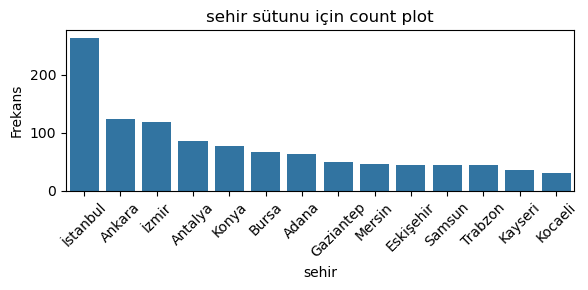

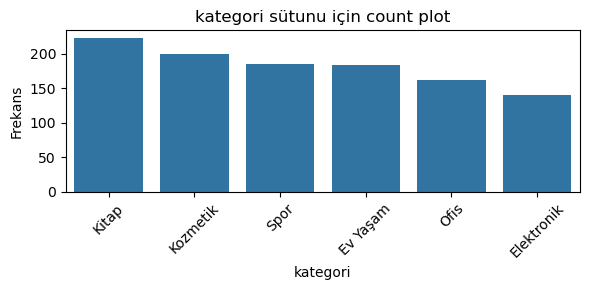

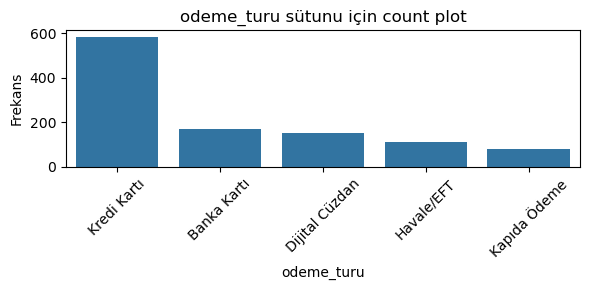

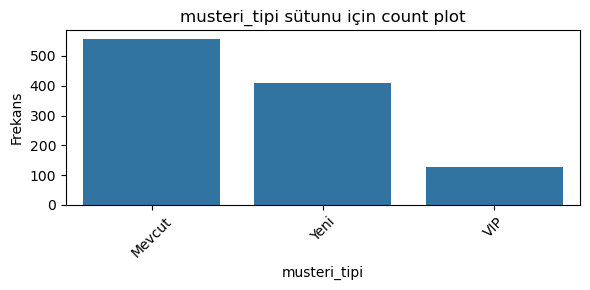

In [10]:
# 9. belirli sütunlar için count plot çizdirme
for sutun in detayli_analiz_sutunlari:
  if sutun in df.columns:
    plt.figure(figsize = (6,3))
    sns.countplot(data = df, x = sutun, order = df[sutun].value_counts().index)
    plt.title(f"{sutun} sütunu için count plot")
    plt.xlabel(sutun)
    plt.ylabel("Frekans")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

## Sayısal Veri Analizi

Amaç:

1. Veri setindeki analiz için uygun sayısal sütunları incelemek
2. Temel istatistikler ve histogram ile dağılım yapısını değerlendirmek

Adımlar:

1. Veri setini yüklemek
2. Sayısal sütunları belirlemek
3. Analiz için uygun sayısal sütunları seçmek
4. Seçilen sütunların genel bilgisini incelemek
5. Temel istatistikleri hesapla
6. Histogram çizdir

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# 1. veri setini yükleme
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")

In [20]:
# 2. sayısal tipteki sütunları belirle
sayisal_sutunlar = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()
sayisal_sutunlar

['adet',
 'birim_fiyat',
 'indirim_orani',
 'kargo_ucreti',
 'teslimat_gunu',
 'musteri_puani',
 'kar_marji_orani',
 'toplam_tutar',
 'siparis_yili',
 'siparis_ayi',
 'siparis_gunu']

In [21]:
# 3. analiz için uygun sayısal sütunlar
analiz_sutunlari  = ["birim_fiyat", "toplam_tutar" ,"teslimat_gunu", "musteri_puani"]

In [22]:
# 4. seçilen sutunların genel bilgisini incele
for sutun in analiz_sutunlari:
  if sutun in df.columns:
    print(f"Sütun: {sutun}")
    print(f"Veri tipi: {df[sutun].dtype}")
    print(f"Benzersiz değer sayısı: {df[sutun].nunique()}")
    print()

Sütun: birim_fiyat
Veri tipi: float64
Benzersiz değer sayısı: 1080

Sütun: toplam_tutar
Veri tipi: float64
Benzersiz değer sayısı: 1092

Sütun: teslimat_gunu
Veri tipi: float64
Benzersiz değer sayısı: 7

Sütun: musteri_puani
Veri tipi: float64
Benzersiz değer sayısı: 3



In [23]:
# 5. temel istatistikleri hesapla
df[analiz_sutunlari].describe()

,birim_fiyat,toplam_tutar,teslimat_gunu,musteri_puani
count,1095.000000,1095.000000,1095.000000,1095.000000
mean,436.698950,779.359014,3.315068,4.282192
std,363.625045,631.014875,1.441834,0.707625
min,93.110000,89.680000,1.000000,3.000000
25%,192.955000,294.815000,2.000000,4.000000
50%,262.050000,565.580000,3.000000,4.000000
75%,583.895000,1017.895000,4.000000,5.000000
max,1742.850000,2990.840000,7.000000,5.000000


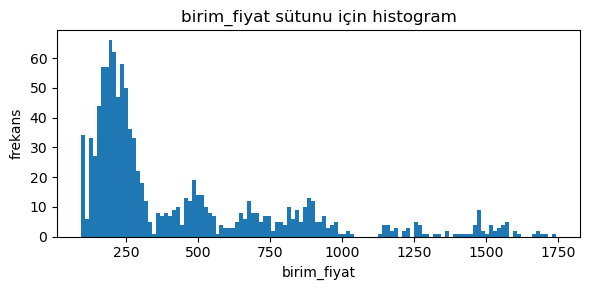

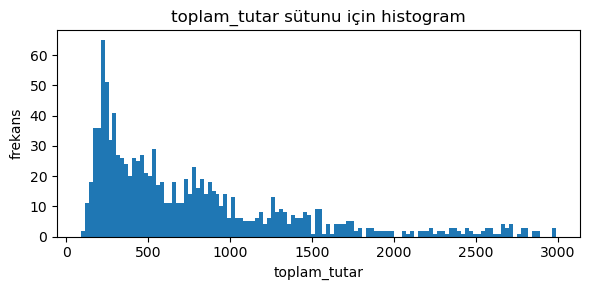

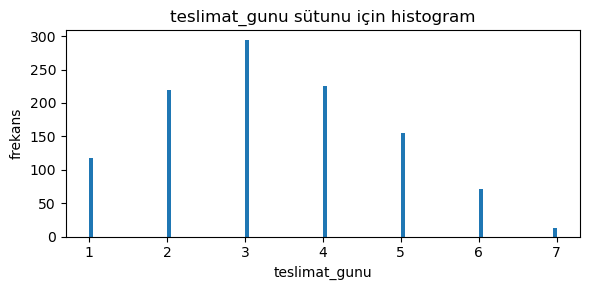

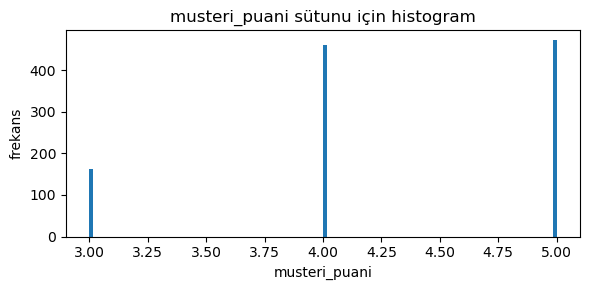

In [24]:
# 6. histogram çizdirme
for sutun in analiz_sutunlari:
  if sutun in df.columns:
    plt.figure(figsize = (6,3))
    plt.hist(df[sutun], bins = 120)
    plt.title(f"{sutun} sütunu için histogram")
    plt.xlabel(sutun)
    plt.ylabel("frekans")
    plt.tight_layout()
    plt.show()

## Grup Bazlı Analiz

Amaç:

1. Veri setini farklı kırılımlara ayırarak grup bazlı analiz yapalım
2. groupby yapısı ile özet istatistikler üretip sonuçları yorumlamak

Adımlar:

1. Veri setini yüklemek
2. Grup bazlı analiz için kullanılacak sütunları belirle
3. Kategoriye göre temel analiz
4. Şehre göre temel analiz
5. Müşteri tipine göre temel analiz
6. Ödeme türüne göre temel analiz
7. Birden fazla sütun ile grup bazlı analiz

In [25]:
import pandas as pd
pd.set_option("display.max_columns", None)

In [26]:
# 1. veri setini yükleyelim
# 2. grup bazlı analiz için kullanılacak sütunları belirle
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,29.9,Banka Kartı,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [27]:
# 3. kategoriye göre temel analiz
kategori_analizi = df.groupby("kategori").agg(
    {
        "toplam_tutar": ["count", "mean", "sum"],
        "birim_fiyat": "mean",
        "musteri_puani": "mean",
        "teslimat_gunu": "mean"
    }
).round(1)
kategori_analizi

toplam_tutar                   birim_fiyat musteri_puani  \
                  count    mean       sum        mean          mean   
kategori                                                              
Elektronik          140  1520.9  212930.3      1065.5           4.2   
Ev Yaşam            184   773.6  142335.6       366.7           4.3   
Kitap               223   511.5  114075.6       224.8           4.3   
Kozmetik            200   737.6  147522.9       373.6           4.4   
Ofis                162   290.4   47051.9       138.2           4.2   
Spor                186  1018.7  189481.9       614.5           4.3   

           teslimat_gunu  
                    mean  
kategori                  
Elektronik           3.3  
Ev Yaşam             3.4  
Kitap                3.4  
Kozmetik             3.4  
Ofis                 3.1  
Spor                 3.2

In [28]:
# 4. şehre göre temel analiz yapalım
sehir_analiz = df.groupby("sehir").agg(
    {
        "toplam_tutar": ["sum", "mean"],
        "teslimat_gunu": "mean",
        "musteri_puani": "mean"
    }
).round(1)
sehir_analiz

toplam_tutar        teslimat_gunu musteri_puani
                   sum   mean          mean          mean
sehir                                                    
Adana          50353.3  799.3           3.5           4.3
Ankara         96721.1  780.0           3.1           4.2
Antalya        63712.8  740.8           3.5           4.3
Bursa          46782.8  698.3           3.5           4.2
Eskişehir      37550.0  834.4           3.2           4.2
Gaziantep      35240.3  719.2           3.4           4.3
Kayseri        24878.8  691.1           3.6           4.3
Kocaeli        21293.0  686.9           3.3           4.2
Konya          59424.3  771.7           3.3           4.4
Mersin         38043.9  827.0           3.5           4.2
Samsun         36263.5  805.9           3.3           4.4
Trabzon        30395.2  690.8           3.4           4.2
İstanbul      224020.6  848.6           3.3           4.4
İzmir          88718.5  751.9           3.1           4.2

In [29]:
# 5. müşteri tipine göre temel analiz
musteri_tipi_analiz = df.groupby("musteri_tipi").agg(
    {
        "toplam_tutar": ["sum", "mean"],
        "teslimat_gunu": "mean",
        "musteri_puani": "mean"
    }
).round(1)
musteri_tipi_analiz

toplam_tutar        teslimat_gunu musteri_puani
                      sum   mean          mean          mean
musteri_tipi                                                
Mevcut           442921.1  793.8           3.3           4.3
VIP              107110.0  836.8           3.4           4.3
Yeni             303367.0  741.7           3.3           4.3

In [30]:
# 6. ödeme türüne göre temel analiz
odeme_turu_analizi = df.groupby("odeme_turu").agg(
    {
        "toplam_tutar": ["sum", "mean"],
        "teslimat_gunu": "mean",
        "musteri_puani": "mean"
    }
).round(1)
odeme_turu_analizi

toplam_tutar        teslimat_gunu musteri_puani
                        sum   mean          mean          mean
odeme_turu                                                    
Banka Kartı        143011.1  846.2           3.5           4.2
Dijital Cüzdan     129911.2  849.1           3.3           4.3
Havale/EFT          92894.5  836.9           3.1           4.2
Kapıda Ödeme        48113.2  609.0           3.2           4.4
Kredi Kartı        439468.2  753.8           3.3           4.3

In [31]:
# 7. birden fazla sütun ile grup bazlı analiz
kategori_musteri_tipi_analizi = df.groupby(["kategori", "musteri_tipi"]).agg(
    {
        "toplam_tutar": ["mean", "sum"],
        "musteri_puani": "mean",
        "teslimat_gunu": "mean"
    }
).round(1)
kategori_musteri_tipi_analizi

toplam_tutar           musteri_puani teslimat_gunu
                                mean       sum          mean          mean
kategori   musteri_tipi                                                   
Elektronik Mevcut             1592.5  122623.6           4.3           3.4
           VIP                1392.6   26459.9           4.0           3.2
           Yeni               1451.1   63846.8           4.2           3.3
Ev Yaşam   Mevcut              798.0   76611.8           4.3           3.5
           VIP                 837.7   18428.6           4.3           3.5
           Yeni                716.6   47295.1           4.2           3.4
Kitap      Mevcut              481.4   53918.5           4.3           3.5
           VIP                 577.9   15604.2           4.1           3.6
           Yeni                530.4   44552.8           4.2           3.2
Kozmetik   Mevcut              720.0   80644.4           4.3           3.4
           VIP                 725.9   20325.0           4.5           3.8
           Yeni                775.9   46553.4           4.6           3.1
Ofis       Mevcut              276.4   19900.3           4.3           3.1
           VIP                 252.7    3538.3           4.1           2.6
           Yeni                310.7   23613.4           4.2           3.3
Spor       Mevcut             1002.5   89222.5           4.3           3.1
           VIP                1264.1   22753.9           4.4           3.0
           Yeni                981.1   77505.5           4.2           3.3

## Pivot Tablo Analizi

Amaç:

1. Veri setini iki yönli kırılımlar ile özetleyerek pivot tablo mantığını kavramak
2. Pivot tablo ile karşılaştırmalı analizler ve sonuçların yorumlanması

Adımlar:

1. veri setini yükle
2. Kategori ve müşteri tipine göre pivot tablo analizi
3. Şehir ve ödeme türüne göre pivot tablo analizi
4. Kategori ve ödeme türüne göre pivot tablo analizi
5. Şehir ve müşteri tipine göre pivot tablo analizi

In [33]:
# 1. veri setini yükle
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,29.9,Banka Kartı,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [34]:
# 2. kategori ve müşteri tipine göre pivot tablo analizi
# her kategori için müşteri tiplerine göre ortalama toplam tutar
pivot_kategori_musteri = pd.pivot_table(
    df,
    index = "kategori",
    columns = "musteri_tipi",
    values = "toplam_tutar",
    aggfunc = "mean"
).round(1)
pivot_kategori_musteri

musteri_tipi,Mevcut,VIP,Yeni
kategori,,,
Elektronik,1592.5,1392.6,1451.1
Ev Yaşam,798.0,837.7,716.6
Kitap,481.4,577.9,530.4
Kozmetik,720.0,725.9,775.9
Ofis,276.4,252.7,310.7
Spor,1002.5,1264.1,981.1


In [35]:
# 3. şehir ve ödeme türü göre pivot tablo analizi
# her kategori için müşteri tiplerine göre ortalama toplam tutar
pivot_sehir_odeme_turu = pd.pivot_table(
    df,
    index = "sehir",
    columns = "odeme_turu",
    values = "toplam_tutar",
    aggfunc = "sum"
).round(1)
pivot_sehir_odeme_turu

odeme_turu,Banka Kartı,Dijital Cüzdan,Havale/EFT,Kapıda Ödeme,Kredi Kartı
sehir,,,,,
Adana,9186.0,9134.0,5565.5,2466.4,24001.3
Ankara,13764.1,13798.7,12892.8,7329.5,48936.1
Antalya,10871.3,7115.7,6658.0,5511.6,33556.2
Bursa,3694.8,8030.9,5853.7,6095.0,23108.3
Eskişehir,4313.3,8010.6,707.9,3395.3,21122.9
Gaziantep,4930.2,7119.0,3746.8,1395.0,18049.3
Kayseri,2957.4,2655.7,6466.2,3307.6,9491.8
Kocaeli,1579.2,5792.3,2891.3,2839.0,8191.2
Konya,15601.8,9379.3,4163.0,2611.8,27668.4


In [36]:
# 4. kategori ve ödeme türüne göre pivot tablo analizi
pivot_kategori_odeme = pd.pivot_table(
    df,
    index = "kategori",
    columns =  "odeme_turu",
    values = "musteri_puani",
    aggfunc = "mean"
).round(2)
pivot_kategori_odeme

odeme_turu,Banka Kartı,Dijital Cüzdan,Havale/EFT,Kapıda Ödeme,Kredi Kartı
kategori,,,,,
Elektronik,4.04,4.25,4.28,4.43,4.28
Ev Yaşam,4.16,4.23,4.00,4.21,4.36
Kitap,4.25,4.22,4.00,4.62,4.27
Kozmetik,4.48,4.33,4.36,4.53,4.41
Ofis,4.29,4.15,4.30,4.31,4.23
Spor,4.20,4.39,4.07,4.15,4.28


In [37]:
# 5. şehir ve müşteri tipi göre pivot tablo analizi
pivot_sehir_musteri = pd.pivot_table(
    df,
    index = "sehir",
    columns =  "musteri_tipi",
    values = "kargo_ucreti",
    aggfunc = "mean"
).round(2)
pivot_sehir_musteri

musteri_tipi,Mevcut,VIP,Yeni
sehir,,,
Adana,40.16,34.92,42.12
Ankara,41.82,37.06,39.91
Antalya,38.63,36.57,40.19
Bursa,38.62,39.90,40.23
Eskişehir,36.38,39.90,39.04
Gaziantep,38.66,45.61,41.58
Kayseri,43.37,45.90,41.90
Kocaeli,42.63,46.57,40.49
Konya,38.12,35.92,39.90


## Veri Görselleştirme

Amaç:

1. Veri setindeki farklı değişkenleri uygun grafik türüyle görselleştirmek
2. Grafikler üzerinden zaman değişimi, ilişki, karşılaştırma ve dağılım yapısını incelemek

Adımlar:

1. Veri setini yüklemek
2. Line plot ile zaman içindeki değişimi görselleştirmek
3. Scatter plot ile iki sayısal değişken arasındaki ilişkiyi görselleştirmek
4. Bar plot ile karşılaştırmalı görselleştirme yapmak
5. Histogram ile sayısal dağılım görselleştirmek
6. Box plot ile dağılım ve aykırı değer tespiti

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme()

In [3]:
# 1. veri setini yükle
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [4]:
# 2. line plot ile zaman içindeki değişimi görselleştirelim
# siparis tarihini date time a çevirelim
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [5]:
aylik_toplam_tutar = df.groupby("siparis_ayi")["toplam_tutar"].sum().reset_index()
aylik_toplam_tutar

,siparis_ayi,toplam_tutar
0,1,68309.45
1,2,67984.01
2,3,70857.89
3,4,68630.39
4,5,92213.41
5,6,77526.88
6,7,68774.62
7,8,55945.11
8,9,80591.62
9,10,60860.45


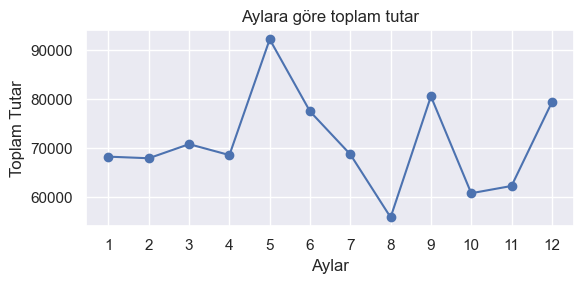

In [6]:
plt.figure(figsize = (6,3))
plt.plot(aylik_toplam_tutar["siparis_ayi"], aylik_toplam_tutar["toplam_tutar"], marker = "o") # line plot
plt.title("Aylara göre toplam tutar")
plt.xlabel("Aylar")
plt.ylabel("Toplam Tutar")
plt.xticks(aylik_toplam_tutar["siparis_ayi"])
plt.tight_layout()
plt.show()

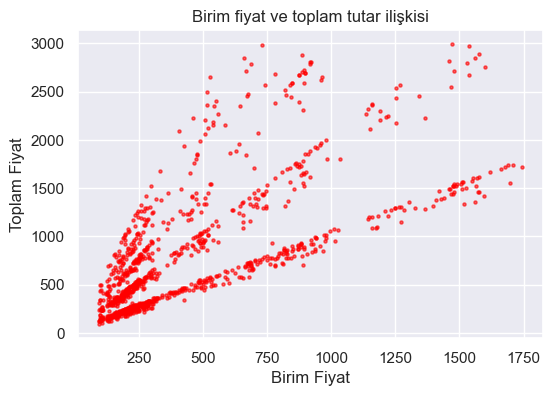

In [7]:
# 3. scatter plot ile iki sayısal değişken arasındaki ilişkiyi görselleştirelim
plt.figure(figsize = (6,4))
plt.scatter(df["birim_fiyat"], df["toplam_tutar"], alpha = 0.6, color = "red", s = 5)
plt.title("Birim fiyat ve toplam tutar ilişkisi")
plt.xlabel("Birim Fiyat")
plt.ylabel("Toplam Fiyat")
plt.show()

In [8]:
# 4. bar plot ile karşılaştırmalı görselleştirme
# kategoriye göre toplam tutarı toplayıp bar plot ile görselleştirme
kategori_toplam_tutar = (
    df.groupby("kategori")["toplam_tutar"]
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)
kategori_toplam_tutar

,kategori,toplam_tutar
0,Elektronik,212930.29
1,Spor,189481.91
2,Kozmetik,147522.90
3,Ev Yaşam,142335.55
4,Kitap,114075.59
5,Ofis,47051.88


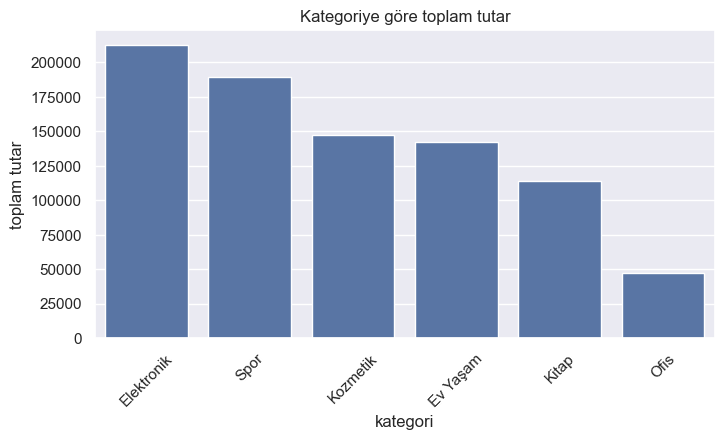

In [9]:
plt.figure(figsize = (8,4))
sns.barplot(data = kategori_toplam_tutar, x = "kategori", y = "toplam_tutar")
plt.title("Kategoriye göre toplam tutar")
plt.xlabel("kategori")
plt.ylabel("toplam tutar")
plt.xticks(rotation = 45)
plt.show()

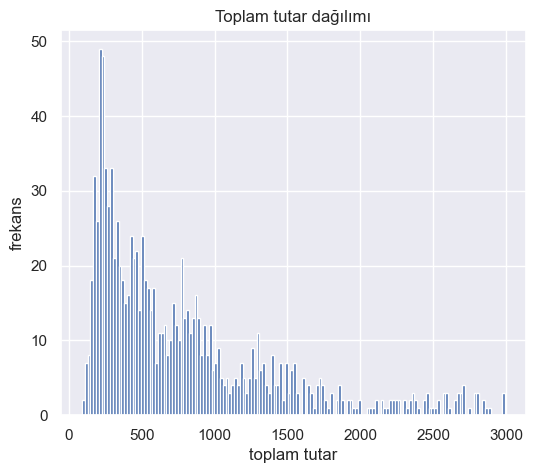

In [10]:
# 5. histogram ile sayısal dağılım görselleştirme
plt.figure(figsize = (6,5))
plt.hist(df["toplam_tutar"], bins = 150)
plt.title("Toplam tutar dağılımı")
plt.xlabel("toplam tutar")
plt.ylabel("frekans")
plt.show()

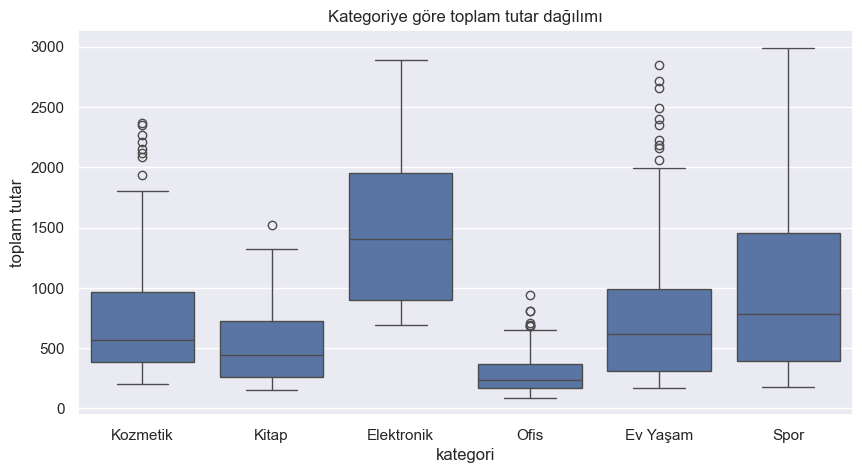

In [11]:
# 6. box plot ile dağılım ve outlier tespiti
plt.figure(figsize = (10,5))
sns.boxplot(data = df, x = "kategori", y = "toplam_tutar")
plt.xlabel("kategori")
plt.ylabel("toplam tutar")
plt.title("Kategoriye göre toplam tutar dağılımı")
plt.show()

## Zaman Serisi Analizi

Amaç:

1. Veri setindeki tarih bilgisini kullanarak zaman bazlı analiz yapmak

Adımlar:

1. Veri setini yüklemek
2. Sipariş tarihini datetime tipine dönüştür
3. Tarih sütunundan zaman özellikleri türet
4. Aylara göre sipariş yoğunluğunu incele
5. Ayın ilk yarısı ve ikinci yarısında ki harcama farkını incele
6. Hafta içi ve hafta sonu sipariş davranışlarını karşılaştırma
7. İki haftalık dönemlerde ortalama sipariş tutarı inceleme

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# 1. veri setinin yüklenmesi
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [14]:
# 2. sipariş tarihini datetime tipine dönüştür
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_tarihi"].dtype

dtype('<M8[ns]')

In [15]:
# 3. tarih sütunundan zaman özellikleri üretelim
df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()
df["hafta_numarasi"] = df["siparis_tarihi"].dt.isocalendar().week.astype(int)
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday,2
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday,32
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday,34
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday,32
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday,31


In [16]:
# 4. aylara göre sipariş yoğunluk
aylik_yogunluk = (
    df.groupby("siparis_ayi")
    .agg(
        siparis_sayisi = ("siparis_id", "count"),
        benzersiz_musteri_sayisi = ("musteri_id", "nunique")
    )
    .reset_index()
    .sort_values("siparis_ayi")
)
aylik_yogunluk

,siparis_ayi,siparis_sayisi,benzersiz_musteri_sayisi
0,1,97,89
1,2,84,75
2,3,94,81
3,4,111,94
4,5,102,94
5,6,85,77
6,7,79,71
7,8,80,71
8,9,91,83
9,10,89,80


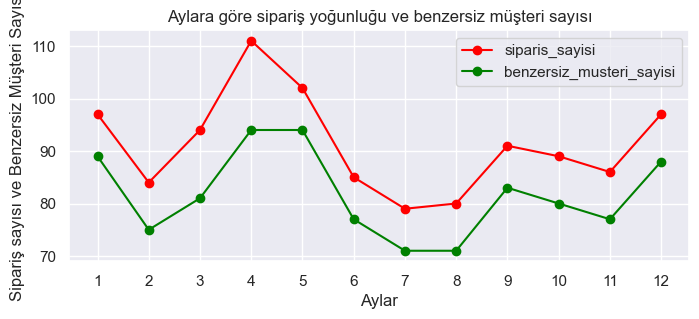

In [17]:
plt.figure(figsize = (8,3))
plt.plot(aylik_yogunluk["siparis_ayi"], aylik_yogunluk["siparis_sayisi"], marker = "o", color = "red", label = "siparis_sayisi")
plt.plot(aylik_yogunluk["siparis_ayi"], aylik_yogunluk["benzersiz_musteri_sayisi"], marker = "o", color = "green", label = "benzersiz_musteri_sayisi")
plt.title("Aylara göre sipariş yoğunluğu ve benzersiz müşteri sayısı")
plt.ylabel("Sipariş sayısı ve Benzersiz Müşteri Sayısı")
plt.xlabel("Aylar")
plt.xticks(aylik_yogunluk["siparis_ayi"])
plt.legend()
plt.show()

In [18]:
# 5. ayın ilk yarısı ve ikinci yarısında ki harcama farkını inceleme
# ayın ilk yarısı ve ikinci yarısı bulma
df["ay_donemi"] = df["siparis_gunu"].apply(
    lambda x: "Ayın ilk yarısı" if x <= 15 else "Ayın ikinci yarısı"
)
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi,ay_donemi
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,5.0,Hayır,0.220,443.68,2024,1,13,Saturday,2,Ayın ilk yarısı
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday,32,Ayın ilk yarısı
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,5.0,Hayır,0.280,2439.03,2024,8,19,Monday,34,Ayın ikinci yarısı
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,5.0,Hayır,0.220,893.94,2025,8,9,Saturday,32,Ayın ilk yarısı
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday,31,Ayın ikinci yarısı


In [19]:
ay_donemi_analizi = (
    df.groupby("ay_donemi")
    .agg(
        toplam_tutar = ("toplam_tutar", "sum")
    )
    .round(1)
    .reset_index()
)
ay_donemi_analizi

,ay_donemi,toplam_tutar
0,Ayın ikinci yarısı,413476.0
1,Ayın ilk yarısı,439922.1


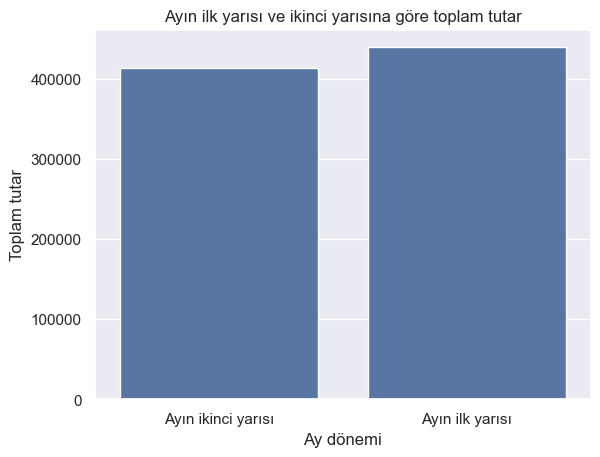

In [20]:
plt.figure()
sns.barplot(data = ay_donemi_analizi, x = "ay_donemi", y= "toplam_tutar")
plt.title("Ayın ilk yarısı ve ikinci yarısına göre toplam tutar")
plt.xlabel("Ay dönemi")
plt.ylabel("Toplam tutar")
plt.show()

In [21]:
# 6. hafta içi ve hafta sonu sipariş davranışını karşılaştırma
df["hafta_tipi"] = df["siparis_tarihi"].dt.dayofweek.apply(
    lambda x: "hafta sonu" if x >=5 else "hafta içi"
)
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi,ay_donemi,hafta_tipi
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Hayır,0.220,443.68,2024,1,13,Saturday,2,Ayın ilk yarısı,hafta sonu
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Hayır,0.250,1023.80,2024,8,10,Saturday,32,Ayın ilk yarısı,hafta sonu
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Hayır,0.280,2439.03,2024,8,19,Monday,34,Ayın ikinci yarısı,hafta içi
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Hayır,0.220,893.94,2025,8,9,Saturday,32,Ayın ilk yarısı,hafta sonu
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Hayır,0.283,1291.26,2024,7,30,Tuesday,31,Ayın ikinci yarısı,hafta içi


In [22]:
hafta_tipi_analizi = (
    df.groupby("hafta_tipi")
    .agg(
        ortalama_siparis_tutari = ("toplam_tutar", "mean"),
    )
    .round(1)
    .reset_index()
)
hafta_tipi_analizi

,hafta_tipi,ortalama_siparis_tutari
0,hafta içi,784.4
1,hafta sonu,767.1


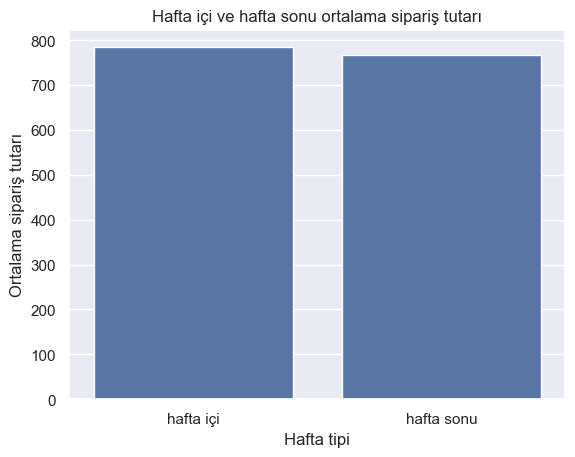

In [23]:
plt.figure()
sns.barplot(data = hafta_tipi_analizi, x = "hafta_tipi", y = "ortalama_siparis_tutari")
plt.title("Hafta içi ve hafta sonu ortalama sipariş tutarı")
plt.xlabel("Hafta tipi")
plt.ylabel("Ortalama sipariş tutarı")
plt.show()

In [24]:
# 7. iki haftalık dönemelerde ortalama sipariş tutarı
df["iki_haftalik_donem"] = ((df["hafta_numarasi"] - 1)//2) + 1
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi,ay_donemi,hafta_tipi,iki_haftalik_donem
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,0.220,443.68,2024,1,13,Saturday,2,Ayın ilk yarısı,hafta sonu,1
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,0.250,1023.80,2024,8,10,Saturday,32,Ayın ilk yarısı,hafta sonu,16
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,0.280,2439.03,2024,8,19,Monday,34,Ayın ikinci yarısı,hafta içi,17
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,0.220,893.94,2025,8,9,Saturday,32,Ayın ilk yarısı,hafta sonu,16
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,0.283,1291.26,2024,7,30,Tuesday,31,Ayın ikinci yarısı,hafta içi,16


In [25]:
iki_haftalik_analiz = (
    df.groupby("iki_haftalik_donem")
    .agg(
        ortalama_siparis_tutari = ("toplam_tutar", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("iki_haftalik_donem")
)
iki_haftalik_analiz

,iki_haftalik_donem,ortalama_siparis_tutari
0,1,744.65
1,2,667.21
2,3,895.91
3,4,822.83
4,5,679.51
5,6,751.62
6,7,773.34
7,8,603.19
8,9,606.74
9,10,876.16


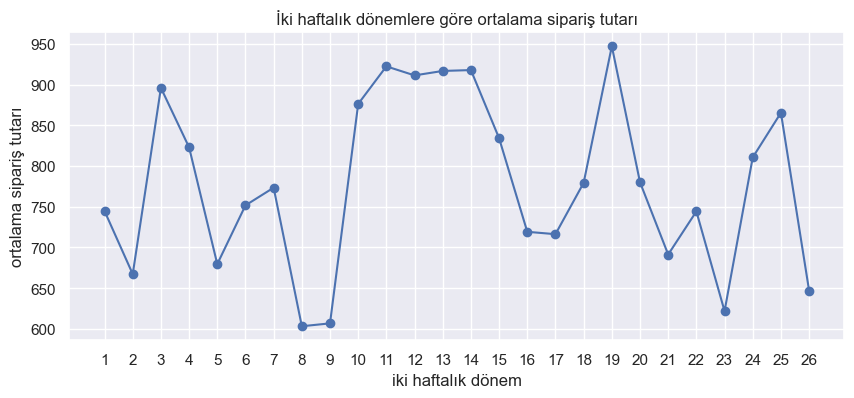

In [26]:
plt.figure(figsize = (10,4))
plt.plot(iki_haftalik_analiz["iki_haftalik_donem"], iki_haftalik_analiz["ortalama_siparis_tutari"], marker = "o")
plt.title("İki haftalık dönemlere göre ortalama sipariş tutarı")
plt.xlabel("iki haftalık dönem")
plt.xticks(iki_haftalik_analiz["iki_haftalik_donem"])
plt.ylabel("ortalama sipariş tutarı")
plt.show()

## Değişkenler Arası İlişkiler

Amaç:

1. Sayısal değişkenler arasındaki ilişkileri korelasyon analizi ile incelemek
2. Heatmap ile görselleştirme yapmak

Adımlar:

1. Veri setini yüklemek
2. Sayısal sütunları belirle
3. Korelasyon matrisi oluştur
4. Korelasyon matrisini heatmap ile görselleştir

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# 1. veri setini yükleme
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [29]:
# 2. sayısal sütunları belirle
sayisal_sutunlar = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()

In [30]:
# 3. korelasyon matrisi
korelasyon_matrisi = df[sayisal_sutunlar].corr()
korelasyon_matrisi

,adet,birim_fiyat,indirim_orani,kargo_ucreti,teslimat_gunu,musteri_puani,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu
adet,1.000000,-0.172071,0.016591,0.033094,0.001184,-0.008471,-0.000069,0.431589,0.029008,0.072723,-0.003461
birim_fiyat,-0.172071,1.000000,-0.002181,0.019820,-0.005320,0.009712,-0.008091,0.715181,-0.028609,-0.029080,-0.033501
indirim_orani,0.016591,-0.002181,1.000000,-0.005396,0.059778,0.008851,-0.009713,-0.029132,0.027660,0.026244,0.016658
kargo_ucreti,0.033094,0.019820,-0.005396,1.000000,-0.007760,0.025023,-0.000559,0.033540,0.078653,-0.013895,0.001687
teslimat_gunu,0.001184,-0.005320,0.059778,-0.007760,1.000000,0.015807,0.007860,0.003866,0.038177,0.002053,-0.023197
musteri_puani,-0.008471,0.009712,0.008851,0.025023,0.015807,1.000000,-0.014840,0.011660,-0.044280,-0.055970,-0.032129
kar_marji_orani,-0.000069,-0.008091,-0.009713,-0.000559,0.007860,-0.014840,1.000000,-0.007492,-0.030443,0.042821,-0.031069
toplam_tutar,0.431589,0.715181,-0.029132,0.033540,0.003866,0.011660,-0.007492,1.000000,-0.006989,0.018804,-0.032507
siparis_yili,0.029008,-0.028609,0.027660,0.078653,0.038177,-0.044280,-0.030443,-0.006989,1.000000,0.047170,-0.032772
siparis_ayi,0.072723,-0.029080,0.026244,-0.013895,0.002053,-0.055970,0.042821,0.018804,0.047170,1.000000,-0.029934


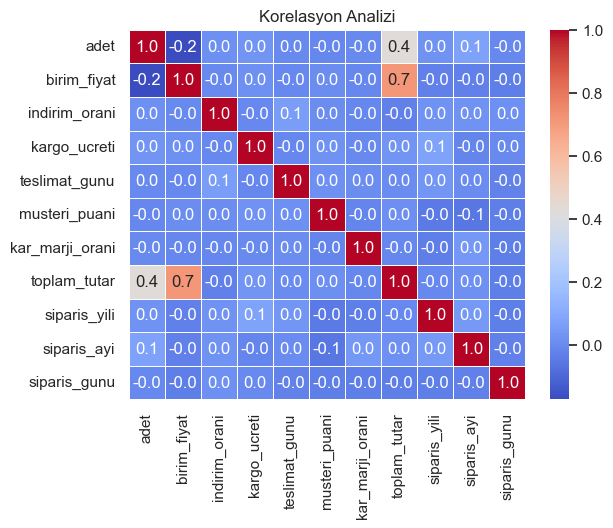

In [31]:
# 4. korelasyon matrisini heatmap ile görselleştirme
sns.heatmap(korelasyon_matrisi, annot = True, fmt = ".1f", cmap = "coolwarm", linewidth = 0.5)
plt.title("Korelasyon Analizi")
plt.show()

## Veri Hikayeleştirme ve İş Yorumu

Amaç:

1. Gerçek hayata benzeyen iş sorularını veri ile cevaplamak
2. Analiz sonuçlarını tablo, grafik ve kısa iş yorumları ile sunmak

Adımlar:

1. Hangi kategori hem yüksek gelir üretiyor hem de müşteri memnuniyeti açısından güçlü görünüyor?
2. Hangi ödeme türleri daha yüksek ortalama sipariş tutarı üretiyor ve müşteri puanı açısından performans gösteriyor?
3. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [34]:
# 1. hangi kategori hem yüksek gelir hem de müşteri memnuniyetini yüksek sağlıyor
kategori_raporu = (
    df.groupby("kategori")
    .agg(
        toplam_gelir = ("toplam_tutar", "sum"),
        ortalama_musteri_puani = ("musteri_puani", "mean")
    )
    .round(2)
)

In [35]:
kategori_raporu = kategori_raporu.sort_values(by = ["toplam_gelir"], ascending=[False])
kategori_raporu

,toplam_gelir,ortalama_musteri_puani
kategori,,
Elektronik,212930.29,4.24
Spor,189481.91,4.26
Kozmetik,147522.90,4.42
Ev Yaşam,142335.55,4.26
Kitap,114075.59,4.25
Ofis,47051.88,4.24


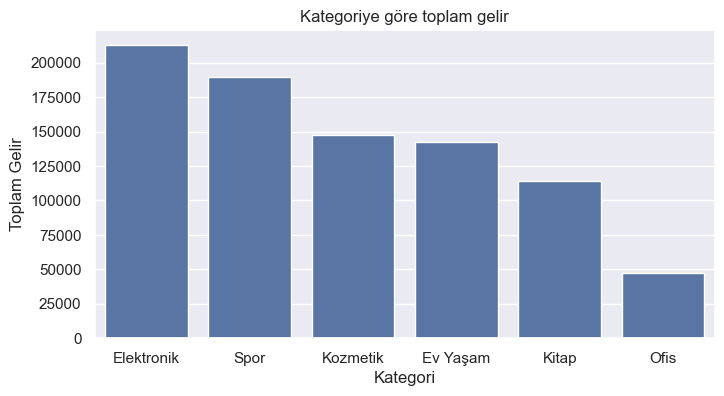

In [36]:
# kategoriye göre toplam gelir
plt.figure(figsize = (8,4))
sns.barplot(data = kategori_raporu, x = "kategori", y = "toplam_gelir")
plt.title("Kategoriye göre toplam gelir")
plt.xlabel("Kategori")
plt.ylabel("Toplam Gelir")
plt.show()

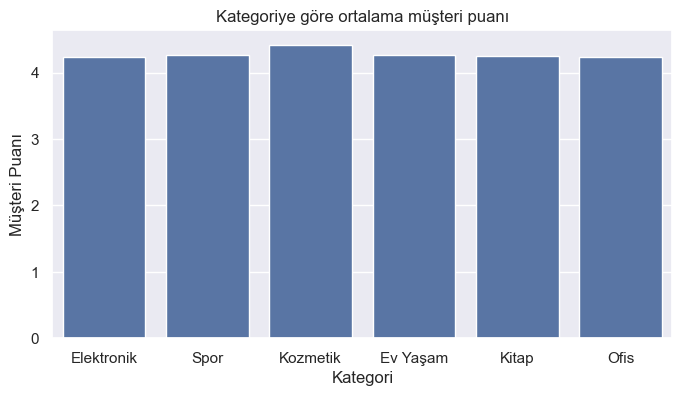

In [37]:
# kategoriye göre ortalama musteri puani
plt.figure(figsize = (8,4))
sns.barplot(data = kategori_raporu, x = "kategori", y = "ortalama_musteri_puani")
plt.title("Kategoriye göre ortalama müşteri puanı")
plt.xlabel("Kategori")
plt.ylabel("Müşteri Puanı")
plt.show()

In [38]:
# 2. hangi ödeme türleri daha yüksek ortalama sipariş tutarı üretiyor ve müşteri puanı açısından nasıl performans gösteriyor?
odeme_turu_raporu = (
    df.groupby("odeme_turu")
    .agg(
        ortalama_siparis_tutari = ("toplam_tutar", "mean"),
        ortalama_musteri_puani = ("musteri_puani", "mean")
    )
    .round(2)
    .sort_values("ortalama_siparis_tutari", ascending = False)
)
odeme_turu_raporu

,ortalama_siparis_tutari,ortalama_musteri_puani
odeme_turu,,
Dijital Cüzdan,849.09,4.27
Banka Kartı,846.22,4.24
Havale/EFT,836.89,4.15
Kredi Kartı,753.80,4.31
Kapıda Ödeme,609.03,4.38


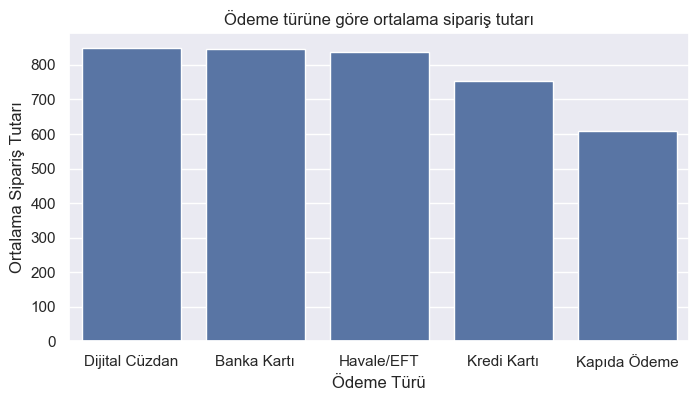

In [39]:
# ödeme türüne göre ortalama sipariş tutarı
plt.figure(figsize = (8,4))
sns.barplot(data = odeme_turu_raporu, x = "odeme_turu", y = "ortalama_siparis_tutari")
plt.title("Ödeme türüne göre ortalama sipariş tutarı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Sipariş Tutarı")
plt.show()

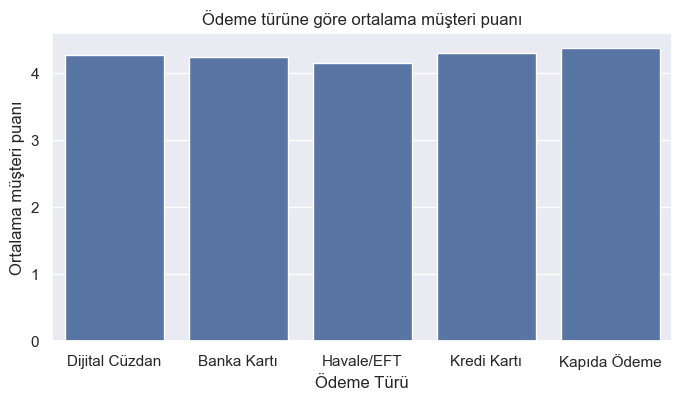

In [40]:
# ödeme türüne göre ortalama müşteri puanı
plt.figure(figsize = (8,4))
sns.barplot(data = odeme_turu_raporu, x = "odeme_turu", y = "ortalama_musteri_puani")
plt.title("Ödeme türüne göre ortalama müşteri puanı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama müşteri puanı")
plt.show()

In [41]:
# 3. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?
sehir_kategori_raporu = (
    df.groupby(["sehir", "kategori"])
    .agg(toplam_gelir = ("toplam_tutar", "sum"))
    .round(2)
    .sort_values(["toplam_gelir"], ascending = False)
)
sehir_kategori_raporu

toplam_gelir
sehir     kategori                
İstanbul  Elektronik      66731.92
          Spor            53391.34
          Ev Yaşam        34130.59
          Kozmetik        33167.28
          Kitap           27106.12
...                            ...
Eskişehir Ofis             1727.90
Kayseri   Elektronik       1715.61
Kocaeli   Ofis             1026.94
Kayseri   Ofis              868.53
Kocaeli   Elektronik        779.13

[84 rows x 1 columns]

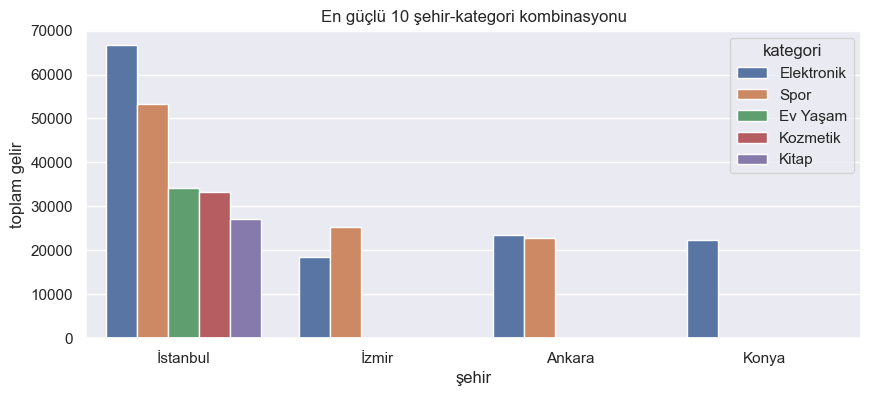

In [42]:
# en güçlü 10 şehir kategori kombinasyonun görselleştir
en_guclu_10_kombinasyon = sehir_kategori_raporu.head(10).reset_index()
plt.figure(figsize = (10,4))
sns.barplot(
    data = en_guclu_10_kombinasyon,
    x = "sehir",
    y = "toplam_gelir",
    hue = "kategori"
)
plt.title("En güçlü 10 şehir-kategori kombinasyonu")
plt.xlabel("şehir")
plt.ylabel("toplam gelir")
plt.show()